In [1]:
"""
MLP_Classifier_60GeV_Holdout

Per-run holdout counterpart to MLP_Classifier_60GeV.ipynb (and the MLP analogue
of CNN_Classifier_60GeV_Holdout.ipynb): entire runs are locked out of training,
then used as the test set. This is the honest measure of whether the flatten +
3-layer MLP generalizes to runs it has never seen, vs. relying on per-run
channel-level shortcuts (dead/noisy channels, pedestal drift) that an MLP --
with one weight per absolute (channel, chip) -- is especially prone to exploit.

Holdout runs: 577 (h/43V), 579 (h/45V), 605 (e/43V), 603 (e/45V) -- one per cell.
Pedestal stats are computed from training events only to avoid leakage.

Trained with BCEWithLogitsLoss on a single logit.
"""


'\nMLP_Classifier_60GeV_Holdout\n\nPer-run holdout counterpart to MLP_Classifier_60GeV.ipynb (and the MLP analogue\nof CNN_Classifier_60GeV_Holdout.ipynb): entire runs are locked out of training,\nthen used as the test set. This is the honest measure of whether the flatten +\n3-layer MLP generalizes to runs it has never seen, vs. relying on per-run\nchannel-level shortcuts (dead/noisy channels, pedestal drift) that an MLP --\nwith one weight per absolute (channel, chip) -- is especially prone to exploit.\n\nHoldout runs: 577 (h/43V), 579 (h/45V), 605 (e/43V), 603 (e/45V) -- one per cell.\nPedestal stats are computed from training events only to avoid leakage.\n\nTrained with BCEWithLogitsLoss on a single logit.\n'

In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import copy
import uproot
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix

def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)


project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


In [3]:
# data loading
labels_df = pd.read_csv(LABELS_CSV)
runs_df = labels_df.query("energy_GeV == 60 and bias_V > 0").copy()
print("runs to load:")
print(runs_df.to_string(index=False))

def find_root_file(run, data_dir=DATA_DIR):
    candidates = list(data_dir.glob(f"Run{run}*.root")) + list(data_dir.glob(f"Run{run:04d}*.root"))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

val_chunks, run_ids, parts, biases = [], [], [], []
for _, row in runs_df.iterrows():
    f = find_root_file(int(row["run"]))
    t = uproot.open(f)["data_tree"]
    n = t.num_entries

    a0 = t["val0_list_0"].array(library="np").reshape(-1, 64, 38)
    a1 = t["val0_list_1"].array(library="np").reshape(-1, 64, 38)
    val_chunks.append(np.stack([a0, a1], axis=1))

    run_ids.append(np.full(n, int(row["run"]),    dtype=np.int32))
    parts.append(  np.full(n, row["particle"],    dtype="U1"))
    biases.append( np.full(n, int(row["bias_V"]), dtype=np.int32))
    print(f"  Run{row.run:03d}: {n:6d} events  ({row.particle}, {row.bias_V}V)")

val0     = np.concatenate(val_chunks, axis=0)
run_id   = np.concatenate(run_ids)
particle = np.concatenate(parts)
bias_v   = np.concatenate(biases)
del val_chunks, run_ids, parts, biases

print(f"\ntotal events: {val0.shape[0]}  shape: {val0.shape}  ({val0.nbytes / 1e9:.2f} GB)")


runs to load:
 run  energy_GeV particle  bias_V
 577          60        h      43
 578          60        h      43
 579          60        h      45
 580          60        h      45
 603          60        e      45
 604          60        e      45
 605          60        e      43
 606          60        e      43
 607          60        e      43
  Run577:  17621 events  (h, 43V)
  Run578:  22362 events  (h, 43V)
  Run579:  20390 events  (h, 45V)
  Run580:  19992 events  (h, 45V)
  Run603:   3432 events  (e, 45V)
  Run604:  10275 events  (e, 45V)
  Run605:  17010 events  (e, 43V)
  Run606:  18581 events  (e, 43V)
  Run607:  17227 events  (e, 43V)

total events: 146890  shape: (146890, 2, 38, 64)  (2.86 GB)


### Per-run holdout configuration

Four runs locked out of training entirely — one per `(particle, bias)` cell. These will only be touched at evaluation time. The model has zero exposure to their channel-level fingerprints.


In [4]:
# Holdout runs: one per (particle, bias) cell.
# Smaller run of each pair preferred where possible (saves more training data).
HOLDOUT_RUNS = [577, 579, 605, 603]

is_holdout = np.isin(run_id, HOLDOUT_RUNS)

print("holdout configuration:")
for rn in HOLDOUT_RUNS:
    m = run_id == rn
    print(f"  Run{rn:03d}: {m.sum():6d} events  ({particle[m][0]}, {bias_v[m][0]}V)")
print(f"\ntotal holdout: {is_holdout.sum()}  training pool: {(~is_holdout).sum()}")


holdout configuration:
  Run577:  17621 events  (h, 43V)
  Run579:  20390 events  (h, 45V)
  Run605:  17010 events  (e, 43V)
  Run603:   3432 events  (e, 45V)

total holdout: 58453  training pool: 88437


### Pedestal normalization (training data only)

Same per-bias quiet-event trick as before — **but** computed from non-holdout events only. The same per-bias normalization is then applied to *every* event (including holdout) using the training-derived statistics. This prevents leakage from the holdout into the model's input distribution.


In [5]:
"""
Per-bias pedestal stats from quiet events in the TRAINING pool only.
Applied to all events using those training-derived statistics.
"""

event_sum = val0.sum(axis=(1, 2, 3))

pedestals = {}
for b in np.unique(bias_v):
    # Quiet events from this bias, training-pool only
    in_bias_train = (bias_v == b) & ~is_holdout
    cutoff = np.percentile(event_sum[in_bias_train], 50)
    quiet  = in_bias_train & (event_sum < cutoff)
    mean = val0[quiet].mean(axis=0).astype(np.float32)
    std  = val0[quiet].std(axis=0).astype(np.float32)
    pedestals[int(b)] = (mean, std)
    print(f"bias {b}V: {quiet.sum():6d} training quiet events  "
          f"mean ADC {mean.min():.1f}..{mean.max():.1f}  avg std {std.mean():.2f}")

val0_norm = np.empty(val0.shape, dtype=np.float32)
for b, (mean, std) in pedestals.items():
    m = bias_v == b
    val0_norm[m] = (val0[m].astype(np.float32) - mean) / (std + 1e-3)

print(f"\nnormalized: shape={val0_norm.shape}  dtype={val0_norm.dtype}")
print(f"training-pool mean: {val0_norm[~is_holdout].mean():+.3f}  (should be ~0)")
print(f"holdout mean:       {val0_norm[is_holdout].mean():+.3f}  (small but not zero is OK)")


bias 43V:  29077 training quiet events  mean ADC 0.0..1023.0  avg std 3.17
bias 45V:  15129 training quiet events  mean ADC 0.0..1023.0  avg std 5.35

normalized: shape=(146890, 2, 38, 64)  dtype=float32
training-pool mean: +0.058  (should be ~0)
holdout mean:       +0.094  (small but not zero is OK)


### Dataset + train / val / holdout split

- **Holdout test**: all events from the 4 holdout runs (touched only at eval time)
- **Train + val**: non-holdout events, per-event stratified split on `(particle, bias)`
  - 85% train, 15% val (val is for early stopping during training)
- The classifier sees the same input layout as before: `(N, 3, 64, 38)` with bias as the 3rd channel.


In [6]:
# Build the 3-channel input tensor (same as Classifier_60GeV)
bias_norm = (bias_v.astype(np.float32) - 44.0)  # 43 -> -1, 45 -> +1
bias_ch   = np.broadcast_to(bias_norm[:, None, None, None],
                            (len(val0_norm), 1, 64, 38)).astype(np.float32)
x_tensor  = np.concatenate([val0_norm, bias_ch], axis=1)
y_tensor  = (particle == "e").astype(np.int64)

print(f"x: {x_tensor.shape}  {x_tensor.nbytes / 1e9:.2f} GB")
print(f"y: {y_tensor.shape}  label counts: "
      f"{dict(zip(['h', 'e'], np.bincount(y_tensor)))}")

# Holdout = entire runs in HOLDOUT_RUNS
holdout_idx = np.where(is_holdout)[0]
pool_idx    = np.where(~is_holdout)[0]

# Per-event stratified train/val split on the pool (non-holdout events)
strat_pool = np.array([f"{p}_{b}" for p, b in zip(particle[pool_idx], bias_v[pool_idx])])
idx_train, idx_val = train_test_split(
    pool_idx, test_size=0.15, stratify=strat_pool, random_state=0,
)
print(f"\nsplit sizes:  train {len(idx_train)}  val {len(idx_val)}  holdout {len(holdout_idx)}")

# Verify each split has all (particle, bias) cells represented
for name, idx in [("train  ", idx_train), ("val    ", idx_val), ("holdout", holdout_idx)]:
    s = [f"{p}_{b}" for p, b in zip(particle[idx], bias_v[idx])]
    counts = {k: int((np.array(s) == k).sum()) for k in sorted(np.unique(s))}
    print(f"  {name}: {counts}")

# Loaders
ds = TensorDataset(torch.from_numpy(x_tensor), torch.from_numpy(y_tensor))
train_ds   = Subset(ds, idx_train)
val_ds     = Subset(ds, idx_val)
holdout_ds = Subset(ds, holdout_idx)

BATCH = 256
train_loader   = DataLoader(train_ds,   batch_size=BATCH,     shuffle=True,  num_workers=0)
val_loader     = DataLoader(val_ds,     batch_size=BATCH * 2, shuffle=False, num_workers=0)
holdout_loader = DataLoader(holdout_ds, batch_size=BATCH * 2, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(f"\nbatch x: {tuple(xb.shape)} {xb.dtype}   y: {tuple(yb.shape)} {yb.dtype}")


x: (146890, 3, 38, 64)  4.29 GB
y: (146890,)  label counts: {'h': np.int64(80365), 'e': np.int64(66525)}

split sizes:  train 75171  val 13266  holdout 58453
  train  : {np.str_('e_43'): 30437, np.str_('e_45'): 8734, np.str_('h_43'): 19007, np.str_('h_45'): 16993}
  val    : {np.str_('e_43'): 5371, np.str_('e_45'): 1541, np.str_('h_43'): 3355, np.str_('h_45'): 2999}
  holdout: {np.str_('e_43'): 17010, np.str_('e_45'): 3432, np.str_('h_43'): 17621, np.str_('h_45'): 20390}

batch x: (256, 3, 38, 64) torch.float32   y: (256,) torch.int64


### Model

Identical to the architecture in `MLP_Classifier_60GeV.ipynb` — flatten the
`(3, 64, 38)` input to 7296 features, then 3 linear layers
(7296→256→64→1) with BatchNorm1d + Dropout(0.3) and a single-logit output.
See that notebook's architecture cell for the rationale and the CNN comparison.

In [7]:
IN_FEATURES = 3 * 64 * 38  # 7296


class MLPClassifier(nn.Module):
    def __init__(self, in_features=IN_FEATURES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                 # (B, 3, 64, 38) -> (B, 7296)
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),             # single logit
        )

    def forward(self, x):
        return self.net(x).squeeze(1)     # (B,)


device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
model = MLPClassifier().to(device)
print(f"device: {device}   params: {sum(p.numel() for p in model.parameters()):,}")


device: mps   params: 1,885,185


### Training

Same loop as the per-event-split MLP notebook: AdamW + ReduceLROnPlateau +
early stopping, `BCEWithLogitsLoss` on a single logit. Weights cached to
`MLP_classifier_60GeV_holdout.pt` (separate from the other caches so they
don't collide).

In [ ]:
MAX_EPOCHS   = 100
PATIENCE     = 12
LR_PATIENCE  = 4
MIN_DELTA    = 1e-4
LR           = 1e-3
WEIGHT_DECAY = 1e-4
RETRAIN      = False
CLASSIFIER_WEIGHTS = PROJECT_ROOT / "Rasmus" / "Classifier" /"MLP_classifier_60GeV_holdout.pt"

history = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}

if CLASSIFIER_WEIGHTS.exists() and not RETRAIN:
    model.load_state_dict(torch.load(CLASSIFIER_WEIGHTS, map_location=device))
    print(f"loaded cached weights from {CLASSIFIER_WEIGHTS.name} (set RETRAIN=True to override)")
else:
    opt       = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6,
    )
    loss_fn = nn.BCEWithLogitsLoss()

    best_val_loss = float("inf")
    best_epoch    = -1
    best_state    = copy.deepcopy(model.state_dict())
    bad_epochs    = 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).float()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(train_ds)

        model.eval()
        va_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                va_loss += loss_fn(logits, yb.float()).item() * xb.size(0)
                correct += ((logits > 0).long() == yb).sum().item()
        va_loss /= len(val_ds)
        va_acc   = correct / len(val_ds)

        scheduler.step(va_loss)
        cur_lr = opt.param_groups[0]["lr"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(cur_lr)

        improved = va_loss < best_val_loss - MIN_DELTA
        if improved:
            best_val_loss = va_loss
            best_epoch    = epoch
            best_state    = copy.deepcopy(model.state_dict())
            bad_epochs    = 0
            tag = " *"
        else:
            bad_epochs += 1
            tag = ""
        print(f"epoch {epoch+1:3d}/{MAX_EPOCHS}  "
              f"train={tr_loss:.4f}  val_loss={va_loss:.4f}  val_acc={va_acc:.3f}  "
              f"lr={cur_lr:.1e}  bad={bad_epochs}{tag}")

        if bad_epochs >= PATIENCE:
            print(f"\nearly stop at epoch {epoch+1}: no improvement for {PATIENCE} epochs")
            break

    model.load_state_dict(best_state)
    torch.save(best_state, CLASSIFIER_WEIGHTS)
    print(f"\nbest val_loss={best_val_loss:.4f}  "
          f"val_acc={history['val_acc'][best_epoch]:.3f} at epoch {best_epoch+1}")
    print(f"saved {CLASSIFIER_WEIGHTS}")


epoch   1/100  train=0.0783  val_loss=0.0219  val_acc=0.994  lr=1.0e-03  bad=0 *
epoch   2/100  train=0.0186  val_loss=0.0193  val_acc=0.994  lr=1.0e-03  bad=0 *
epoch   3/100  train=0.0129  val_loss=0.0212  val_acc=0.993  lr=1.0e-03  bad=1
epoch   4/100  train=0.0096  val_loss=0.0175  val_acc=0.995  lr=1.0e-03  bad=0 *
epoch   5/100  train=0.0084  val_loss=0.0196  val_acc=0.994  lr=1.0e-03  bad=1
epoch   6/100  train=0.0066  val_loss=0.0194  val_acc=0.994  lr=1.0e-03  bad=2
epoch   7/100  train=0.0059  val_loss=0.0185  val_acc=0.995  lr=1.0e-03  bad=3
epoch   8/100  train=0.0053  val_loss=0.0157  val_acc=0.995  lr=1.0e-03  bad=0 *
epoch   9/100  train=0.0059  val_loss=0.0207  val_acc=0.994  lr=1.0e-03  bad=1
epoch  10/100  train=0.0052  val_loss=0.0159  val_acc=0.996  lr=1.0e-03  bad=2
epoch  11/100  train=0.0045  val_loss=0.0208  val_acc=0.994  lr=1.0e-03  bad=3
epoch  12/100  train=0.0038  val_loss=0.0199  val_acc=0.995  lr=1.0e-03  bad=4
epoch  13/100  train=0.0055  val_loss=0.0190

### Val evaluation (same-distribution, for sanity)

Standard per-event eval on the validation set — events that come from the same runs as training. This number should be high (it was 98%+ before). It's just a sanity check that training worked; the **real** number is the per-run holdout eval below.


val accuracy:  0.9954
val AUC:       0.9998
val confusion:
[[6327   27]
 [  34 6878]]


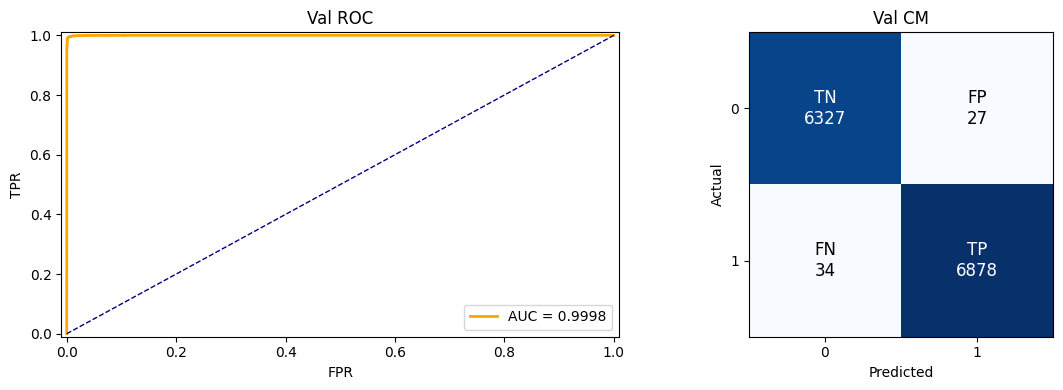

In [11]:
model.eval()
probs_list, labels_list = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs  = torch.sigmoid(logits)
        probs_list.append(probs.cpu().numpy())
        labels_list.append(yb.numpy())
y_prob = np.concatenate(probs_list)
y_true = np.concatenate(labels_list)
y_pred = (y_prob > 0.5).astype(int)

fpr, tpr, _   = roc_curve(y_true, y_prob)
roc_auc       = auc(fpr, tpr)
cm            = confusion_matrix(y_true, y_pred)

print(f"val accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"val AUC:       {roc_auc:.4f}")
print(f"val confusion:\n{cm}")

# Quick plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr, color="orange", lw=2, label=f"AUC = {roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("Val ROC")
ax[0].legend(loc="lower right"); ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual"); ax[1].set_title("Val CM")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{cm[i,j]}", ha="center", va="center",
                   color="white" if cm[i,j] > cm.max() / 2 else "black", fontsize=12)
plt.tight_layout(); plt.show()


### Per-run holdout evaluation — the real test

Run the trained model on the holdout runs and look at:

1. **Per-run breakdown** — accuracy and mean P(electron) per held-out run. A "good" result here looks like:
   - h holdout runs: low mean P(e) (~0.1–0.3), accuracy ~90%+
   - e holdout runs: high mean P(e) (~0.7–0.9), accuracy ~90%+
2. **Overall holdout ROC / AUC / confusion matrix** — the per-event view across all holdouts combined.
3. **Comparison to val accuracy** — the *gap* between val and holdout is the size of the run-fingerprint shortcut.

Likely outcomes:
- **Holdout matches val (~98%)** → the model learned a generalizable feature. Strong result.
- **Holdout drops moderately (~75–85%)** → mix of real learning and shortcut; the per-run pattern will tell you which is dominant per cell.
- **Holdout collapses to ~50%** → the model was riding run-fingerprint shortcuts. The per-event ~98% was misleading.


per-run holdout results:
    run  part.   bias        n   mean P(e)   accuracy
  -------------------------------------------------------
    577      h     43    17621      0.0163     0.9864
    579      h     45    20390      0.0091     0.9925
    605      e     43    17010      0.9986     0.9988
    603      e     45     3432      0.9673     0.9685

overall holdout accuracy: 0.9911
compare to val accuracy:  0.9954
gap (shortcut size):      +0.0043

holdout AUC: 0.9995
holdout confusion:
[[37619   392]
 [  129 20313]]


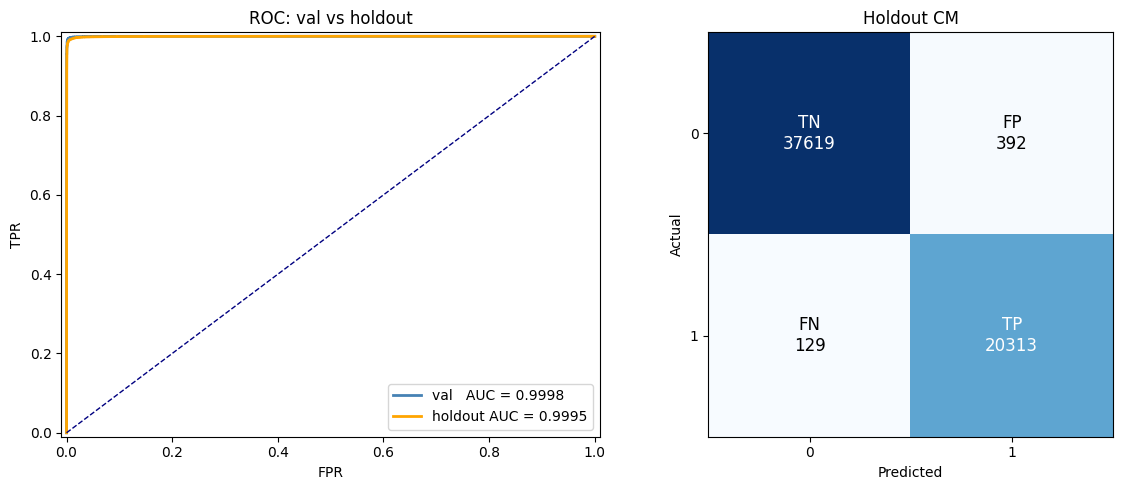

In [12]:
"""
Evaluate the trained model on the held-out runs.
"""

model.eval()
hold_probs = np.empty(len(holdout_idx), dtype=np.float32)
cursor = 0
with torch.no_grad():
    for xb, _ in holdout_loader:
        xb = xb.to(device)
        p = torch.sigmoid(model(xb)).cpu().numpy()
        hold_probs[cursor:cursor + len(p)] = p
        cursor += len(p)

hold_preds = (hold_probs > 0.5).astype(int)
hold_y     = y_tensor[holdout_idx]
hold_run   = run_id[holdout_idx]

# Per-run breakdown
print("per-run holdout results:")
print(f"  {'run':>5}  {'part.':>5}  {'bias':>5}  {'n':>7}  {'mean P(e)':>10}  {'accuracy':>9}")
print("  " + "-" * 55)
for rn in HOLDOUT_RUNS:
    m = hold_run == rn
    if not m.any(): continue
    p = particle[holdout_idx[m]][0]
    b = bias_v[holdout_idx[m]][0]
    mean_pe = hold_probs[m].mean()
    acc     = (hold_preds[m] == hold_y[m]).mean()
    print(f"  {rn:>5}  {p:>5}  {b:>5}  {m.sum():>7}  {mean_pe:>10.4f}  {acc:>9.4f}")

acc_overall = (hold_preds == hold_y).mean()
print(f"\noverall holdout accuracy: {acc_overall:.4f}")
print(f"compare to val accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"gap (shortcut size):      {(y_pred == y_true).mean() - acc_overall:+.4f}")

# ROC + CM on the combined holdout
fpr_h, tpr_h, _ = roc_curve(hold_y, hold_probs)
roc_auc_h       = auc(fpr_h, tpr_h)
cm_h            = confusion_matrix(hold_y, hold_preds)

print(f"\nholdout AUC: {roc_auc_h:.4f}")
print(f"holdout confusion:\n{cm_h}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Overlay val and holdout ROC for direct comparison
ax[0].plot(fpr,   tpr,   color="steelblue", lw=2, label=f"val   AUC = {roc_auc:.4f}")
ax[0].plot(fpr_h, tpr_h, color="orange",    lw=2, label=f"holdout AUC = {roc_auc_h:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[0].set_title("ROC: val vs holdout"); ax[0].legend(loc="lower right")
ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

# Holdout confusion matrix
ax[1].imshow(cm_h, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
ax[1].set_title("Holdout CM")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{cm_h[i,j]}", ha="center", va="center",
                   color="white" if cm_h[i,j] > cm_h.max() / 2 else "black", fontsize=12)
plt.tight_layout(); plt.show()
